## Phase 1: Exploratory Operations Analysis

Goal:
Analyze delivery performance, ETA reliability, delay patterns, courier supply, weather impact, and prepare the dataset for future machine learning.

#### Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../data/raw/orders_spring_2022.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,order_placed_at_utc,order_category,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,venue_location_h3_index,customer_location_h3_index,courier_supply_index,precipitation
0,2022-02-01T06:01:00.000000,Retail,9,23.373547,15.0,25.0,881126d307fffff,881126d307fffff,1.48,0.0
1,2022-02-01T06:16:00.000000,Food delivery,2,72.864126,40.0,50.0,881126d339fffff,881126d311fffff,1.49,0.0
2,2022-02-01T06:46:00.000000,Food delivery,3,48.737269,30.0,40.0,881126d33dfffff,881126d331fffff,1.50,0.0
3,2022-02-01T07:17:00.000000,Food delivery,5,37.744732,35.0,45.0,881126d331fffff,881126d337fffff,1.56,0.0
4,2022-02-01T07:21:00.000000,Retail,15,68.881136,35.0,45.0,881126d06bfffff,881126d027fffff,1.58,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24942 entries, 0 to 24941
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   order_placed_at_utc                    24942 non-null  object 
 1   order_category                         24942 non-null  object 
 2   item_count                             24942 non-null  int64  
 3   actual_delivery_time_minutes           24942 non-null  float64
 4   estimated_delivery_time_lower_minutes  24886 non-null  float64
 5   estimated_delivery_time_upper_minutes  24886 non-null  float64
 6   venue_location_h3_index                24942 non-null  object 
 7   customer_location_h3_index             24942 non-null  object 
 8   courier_supply_index                   24844 non-null  float64
 9   precipitation                          24072 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 1.9+ MB


### Total Number of Null Values Per Column

In [3]:
df.isna().sum()

order_placed_at_utc                        0
order_category                             0
item_count                                 0
actual_delivery_time_minutes               0
estimated_delivery_time_lower_minutes     56
estimated_delivery_time_upper_minutes     56
venue_location_h3_index                    0
customer_location_h3_index                 0
courier_supply_index                      98
precipitation                            870
dtype: int64

### Datetime Conversion and Feature Engineering

In [4]:
df["order_placed_at_utc"] = pd.to_datetime(df["order_placed_at_utc"])

df["order_hour"] = df["order_placed_at_utc"].dt.hour
df["order_day_of_week"] = df["order_placed_at_utc"].dt.day_name()
df["order_date"] = df["order_placed_at_utc"].dt.date
df["is_weekend"] = df["order_placed_at_utc"].dt.dayofweek >= 5

df["estimated_delivery_midpoint"] = (
    df["estimated_delivery_time_lower_minutes"] +
    df["estimated_delivery_time_upper_minutes"]
) / 2

df["eta_error_minutes"] = (
    df["actual_delivery_time_minutes"] - df["estimated_delivery_midpoint"]
)

df["is_late_vs_upper_estimate"] = (
    df["actual_delivery_time_minutes"] > df["estimated_delivery_time_upper_minutes"]
)

df.head()

,order_placed_at_utc,order_category,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,venue_location_h3_index,customer_location_h3_index,courier_supply_index,precipitation,order_hour,order_day_of_week,order_date,is_weekend,estimated_delivery_midpoint,eta_error_minutes,is_late_vs_upper_estimate
0,2022-02-01 06:01:00,Retail,9,23.373547,15.0,25.0,881126d307fffff,881126d307fffff,1.48,0.0,6,Tuesday,2022-02-01,False,20.0,3.373547,False
1,2022-02-01 06:16:00,Food delivery,2,72.864126,40.0,50.0,881126d339fffff,881126d311fffff,1.49,0.0,6,Tuesday,2022-02-01,False,45.0,27.864126,True
2,2022-02-01 06:46:00,Food delivery,3,48.737269,30.0,40.0,881126d33dfffff,881126d331fffff,1.50,0.0,6,Tuesday,2022-02-01,False,35.0,13.737269,True
3,2022-02-01 07:17:00,Food delivery,5,37.744732,35.0,45.0,881126d331fffff,881126d337fffff,1.56,0.0,7,Tuesday,2022-02-01,False,40.0,-2.255268,False
4,2022-02-01 07:21:00,Retail,15,68.881136,35.0,45.0,881126d06bfffff,881126d027fffff,1.58,0.0,7,Tuesday,2022-02-01,False,40.0,28.881136,True


### Initial KPIs on Raw Dataset

In [5]:
kpis = {
    "total_orders": len(df),
    "average_delivery_time": df["actual_delivery_time_minutes"].mean(),
    "median_delivery_time": df["actual_delivery_time_minutes"].median(),
    "late_rate_vs_upper_eta": df["is_late_vs_upper_estimate"].mean(),
    "average_eta_error": df["eta_error_minutes"].mean(),
    "unique_venue_areas": df["venue_location_h3_index"].nunique(),
    "unique_customer_areas": df["customer_location_h3_index"].nunique()
}

kpis

{'total_orders': 24942,
 'average_delivery_time': np.float64(34.655143755979346),
 'median_delivery_time': np.float64(29.732429320500884),
 'late_rate_vs_upper_eta': np.float64(0.35406142250020045),
 'average_eta_error': np.float64(4.181288761985121),
 'unique_venue_areas': 143,
 'unique_customer_areas': 381}

### Distribution of Actual Delivery Time

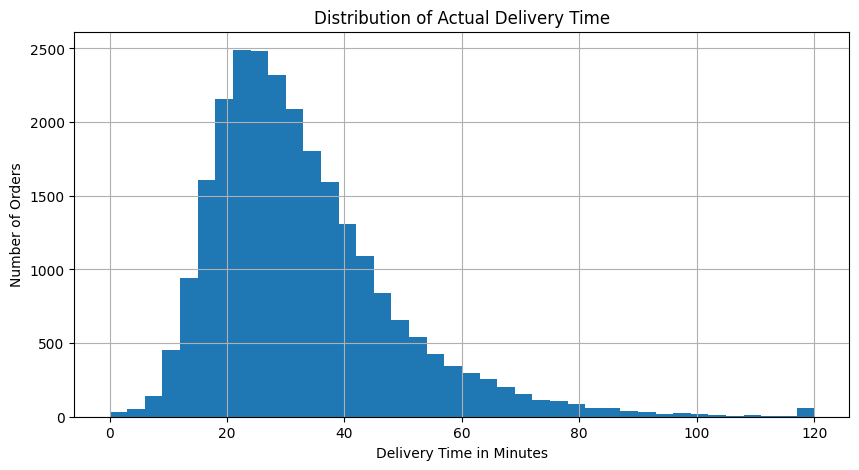

In [6]:
figures_path = Path("../figures")
figures_path.mkdir(exist_ok=True)

plt.figure(figsize=(10,5))
df["actual_delivery_time_minutes"].clip(upper=120).hist(bins=40)
plt.title("Distribution of Actual Delivery Time")
plt.xlabel("Delivery Time in Minutes")
plt.ylabel("Number of Orders")
plt.savefig(figures_path / "delivery_time_distribution.png", bbox_inches="tight")
plt.show()

### Order Volume by Hour of Day

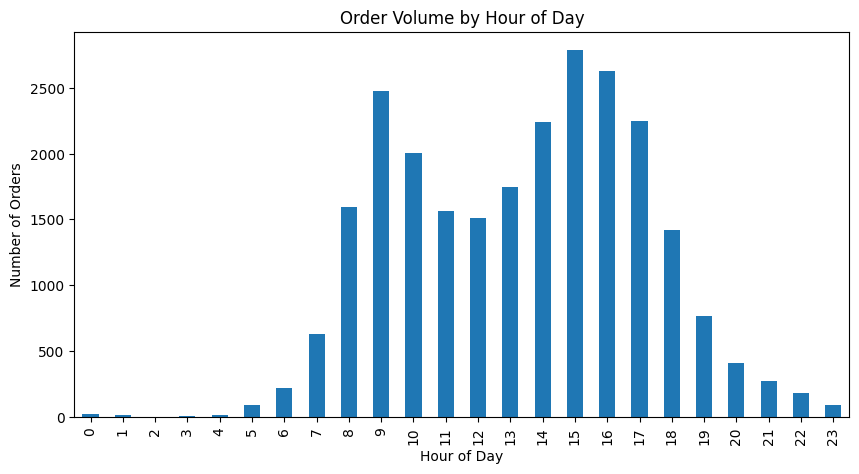

In [7]:
orders_by_hour = df.groupby("order_hour").size()

plt.figure(figsize=(10,5))
orders_by_hour.plot(kind="bar")
plt.title("Order Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.savefig(figures_path / "orders_by_hour.png", bbox_inches="tight")
plt.show()

### Median Delivery Time by Order Category

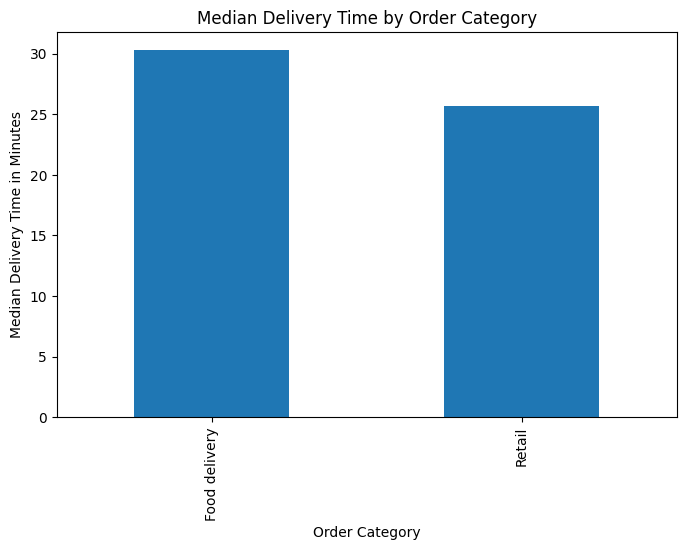

In [8]:
delivery_by_category = df.groupby("order_category")["actual_delivery_time_minutes"].median()

plt.figure(figsize=(8,5))
delivery_by_category.plot(kind="bar")
plt.title("Median Delivery Time by Order Category")
plt.xlabel("Order Category")
plt.ylabel("Median Delivery Time in Minutes")
plt.savefig(figures_path / "median_delivery_time_by_category.png", bbox_inches="tight")
plt.show()

### Average Delivery Time by Hour

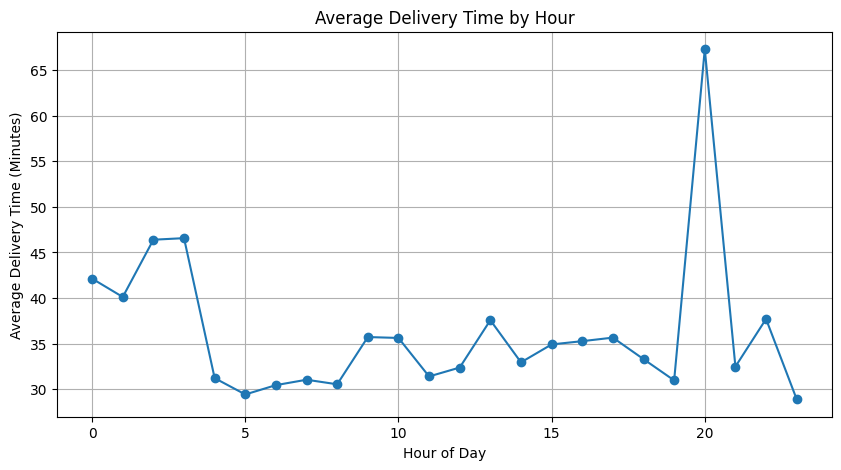

In [9]:
delivery_by_hour = df.groupby("order_hour")["actual_delivery_time_minutes"].mean()

plt.figure(figsize=(10,5))
delivery_by_hour.plot(marker="o")

plt.title("Average Delivery Time by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delivery Time (Minutes)")
plt.grid(True)

plt.savefig(figures_path / "average_delivery_time_by_hour.png", bbox_inches="tight")

plt.show()

### Courier supply vs delivery time

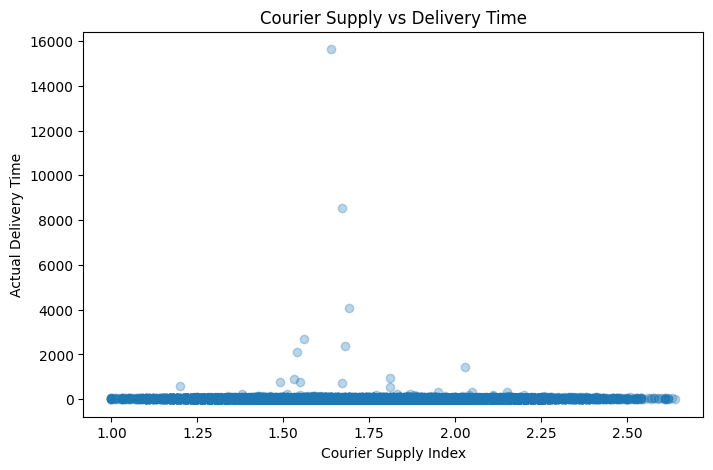

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["courier_supply_index"],
    df["actual_delivery_time_minutes"],
    alpha=0.3
)

plt.title("Courier Supply vs Delivery Time")
plt.xlabel("Courier Supply Index")
plt.ylabel("Actual Delivery Time")

plt.show()

In [11]:
rain_comparison = df.groupby(df["precipitation"] > 0)["actual_delivery_time_minutes"].mean()

rain_comparison

precipitation
False    34.476172
True     35.734322
Name: actual_delivery_time_minutes, dtype: float64

In [12]:
df["actual_delivery_time_minutes"].describe(percentiles=[0.90, 0.95, 0.99])

count    24942.000000
mean        34.655144
std        120.366646
min          0.022010
50%         29.732429
90%         53.086767
95%         63.197052
99%         85.975574
max      15631.062016
Name: actual_delivery_time_minutes, dtype: float64

In [13]:
df.sort_values(
    "actual_delivery_time_minutes",
    ascending=False
).head(20)

,order_placed_at_utc,order_category,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,venue_location_h3_index,customer_location_h3_index,courier_supply_index,precipitation,order_hour,order_day_of_week,order_date,is_weekend,estimated_delivery_midpoint,eta_error_minutes,is_late_vs_upper_estimate
1757,2022-02-06 20:24:00,Food delivery,2,15631.062016,30.0,40.0,881126d339fffff,881126d33dfffff,1.64,0.0,20,Sunday,2022-02-06,True,35.0,15596.062016,True
10180,2022-03-08 13:38:00,Food delivery,2,8537.922448,20.0,30.0,881126d06bfffff,881126d061fffff,1.67,0.0,13,Tuesday,2022-03-08,False,25.0,8512.922448,True
12229,2022-03-15 15:37:00,Food delivery,1,4078.617036,10.0,30.0,881126d1c1fffff,881126d1c1fffff,1.69,0.0,15,Tuesday,2022-03-15,False,20.0,4058.617036,True
6383,2022-02-23 10:59:00,Food delivery,2,2701.378066,40.0,50.0,881126d0a7fffff,881126d001fffff,1.56,0.0,10,Wednesday,2022-02-23,False,45.0,2656.378066,True
19489,2022-04-09 17:15:00,Food delivery,1,2374.103178,5.0,25.0,881126d32bfffff,881126d32bfffff,1.68,0.2,17,Saturday,2022-04-09,True,15.0,2359.103178,True
14539,2022-03-24 09:00:00,Food delivery,1,2126.155989,15.0,35.0,881126d1c1fffff,881126d1c1fffff,1.54,0.0,9,Thursday,2022-03-24,False,25.0,2101.155989,True
22608,2022-04-22 07:41:00,Food delivery,2,1457.894148,20.0,30.0,881126d331fffff,881126d335fffff,2.03,0.0,7,Friday,2022-04-22,False,25.0,1432.894148,True
9397,2022-03-05 16:34:00,Food delivery,2,963.564861,40.0,50.0,881126d285fffff,881126d29bfffff,1.81,NaN,16,Saturday,2022-03-05,True,45.0,918.564861,True
19514,2022-04-09 18:14:00,Food delivery,2,892.269003,30.0,45.0,881126c353fffff,881126c351fffff,1.53,0.2,18,Saturday,2022-04-09,True,37.5,854.769003,True
19529,2022-04-09 18:52:00,Food delivery,1,760.825667,35.0,50.0,881126d56dfffff,881126d563fffff,1.55,0.2,18,Saturday,2022-04-09,True,42.5,718.325667,True


In [14]:
df_filtered = df[df["actual_delivery_time_minutes"] <= 60].copy()

print("Original rows:", len(df))
print("Filtered rows:", len(df_filtered))

removed_percentage = (1 - len(df_filtered) / len(df)) * 100
print("Percentage removed:", round(removed_percentage, 2), "%")

Original rows: 24942
Filtered rows: 23370
Percentage removed: 6.3 %


# Outlier Handling and Filtered Operational Dataset

Initial exploratory analysis revealed several extremely large delivery-time observations, including values exceeding 15,000 minutes.

Since delivery durations above 60 minutes are operationally unusual in the context of urban food delivery operations, a filtered operational analysis dataset was created.

This filtering step improves the interpretability of operational KPIs and reduces distortion caused by anomalous observations.